# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

In [8]:
# I read and skimmed the the sections.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

In [1]:
# I downloaded and uncompressed SUSY.

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [2]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  7588k      0 --:--:--  0:01:58 --:--:-- 6850k


In [4]:
!rm SUSY.csv

In [5]:
!gunzip SUSY.csv.gz

In [1]:
ls -lh

total 12736
-rw-------@ 1 afarbin  staff   389K Mar 16 12:50 Lab.7.ipynb
-rw-------@ 1 afarbin  staff   5.8M Mar  4 12:46 Lab.7.pdf


The data is provided as a comma separated file.

In [2]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [7]:
!ls -lh

total 5148104
-rw-r--r--@ 1 afarbin  staff   389K Oct 18 13:44 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   5.8M Oct 18 12:45 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Oct 18 12:39 SUSY-small.csv
-rw-r--r--  1 afarbin  staff   2.2G Oct 18 13:43 SUSY.csv


We see that we have 5 million datapoints.

In [5]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [10]:
!head -500000 SUSY.csv > SUSY-small.csv

In [11]:
ls -lh

total 5173504
-rw-r--r--@ 1 afarbin  staff   387K Mar 29 11:08 Lab.7.ipynb
-rw-r--r--@ 1 afarbin  staff   6.1M Mar 18 10:38 Lab.7.pdf
-rw-r--r--@ 1 afarbin  staff   228M Mar 29 11:09 SUSY-small.csv
-rw-r--r--@ 1 afarbin  staff   2.2G Mar 18 10:38 SUSY.csv


In [12]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [4]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [5]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [6]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [7]:
FeatureNames

['axial_MET',
 'MET_rel',
 'M_R',
 'cos_theta_r1',
 'MT2',
 'dPhi_r_b',
 'M_TR_2',
 'R',
 'S_R',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [10]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [11]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [11]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


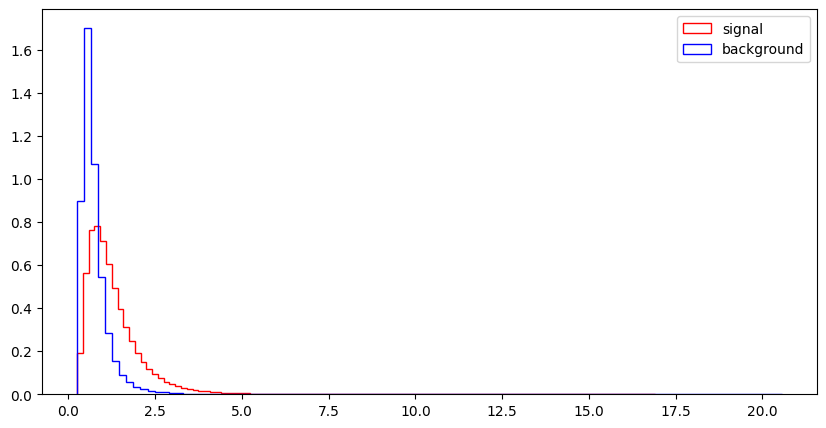

l_1_eta


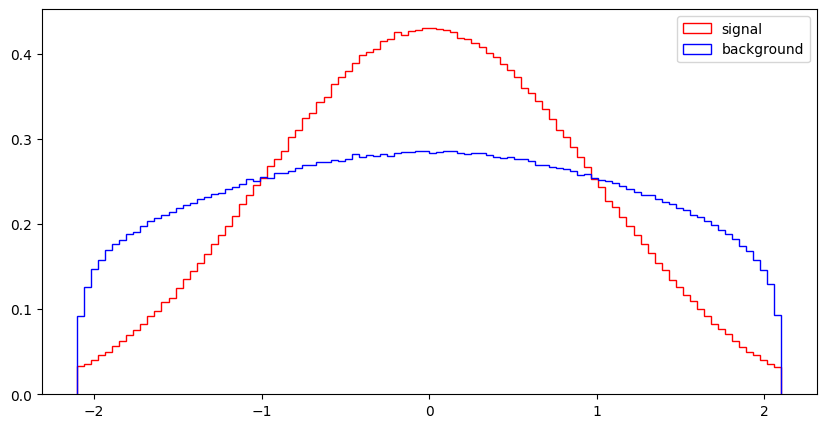

l_1_phi


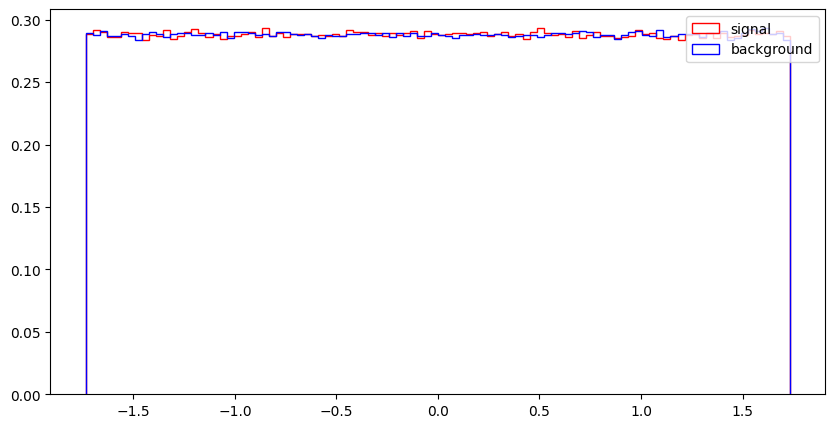

l_2_pT


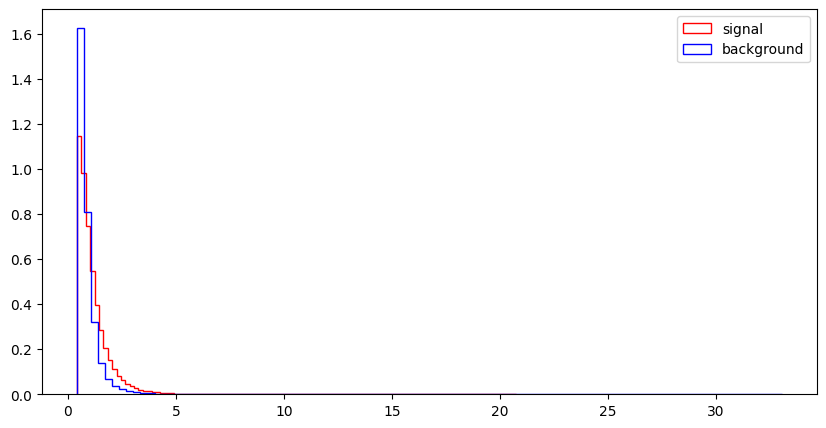

l_2_eta


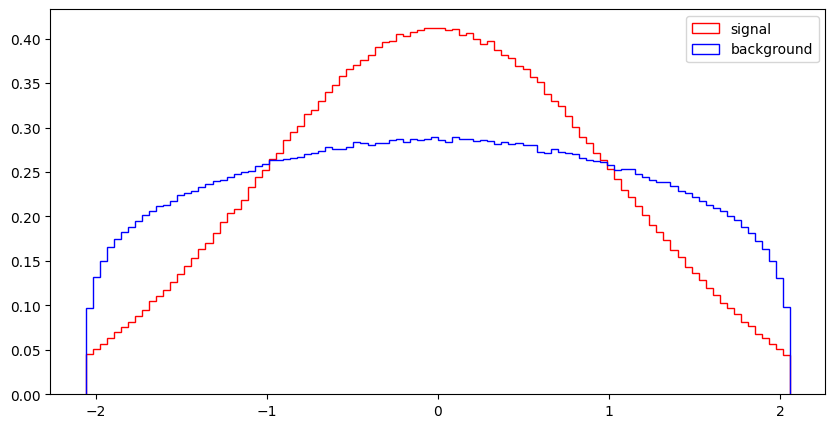

l_2_phi


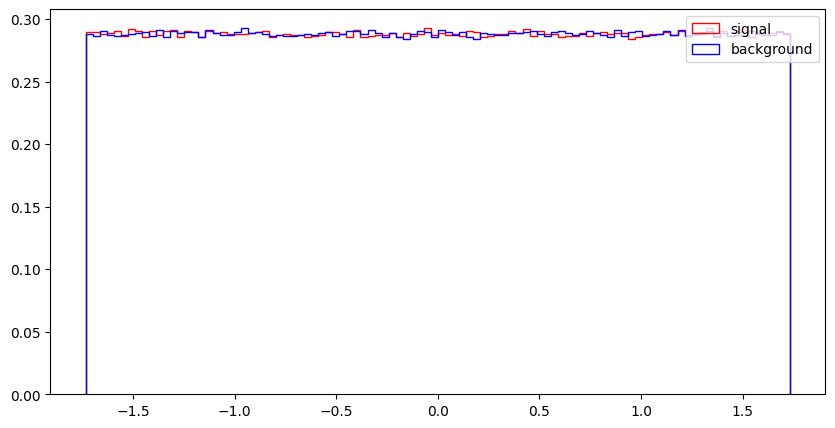

MET


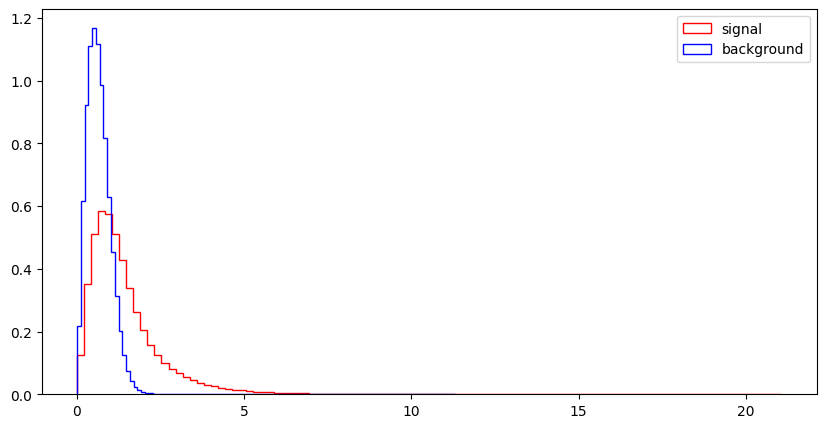

MET_phi


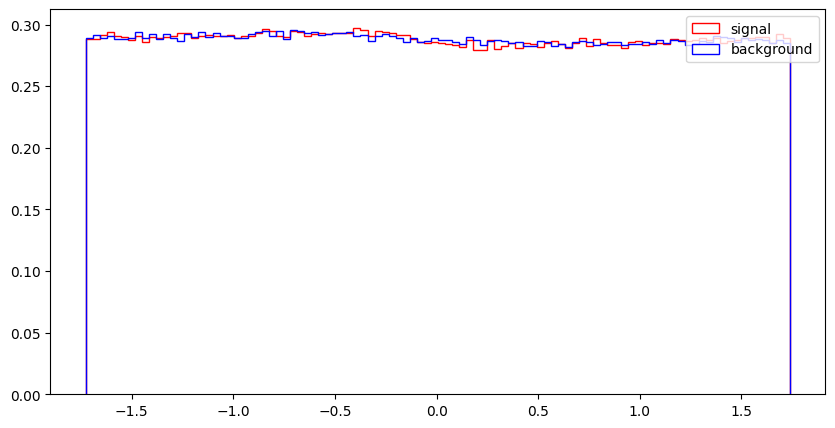

MET_rel


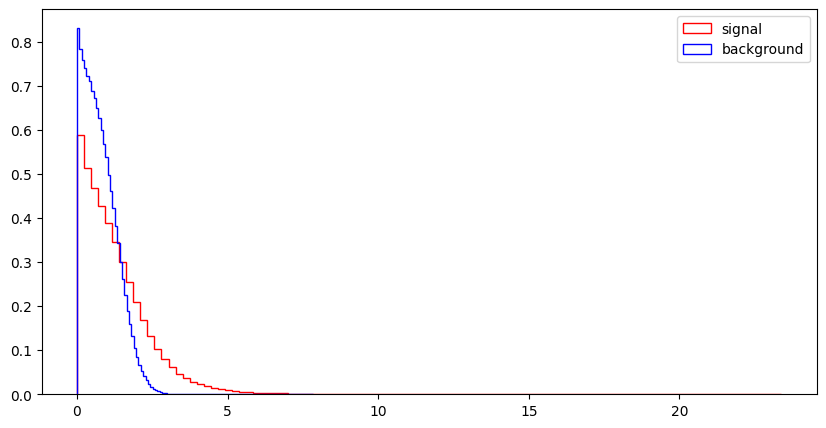

axial_MET


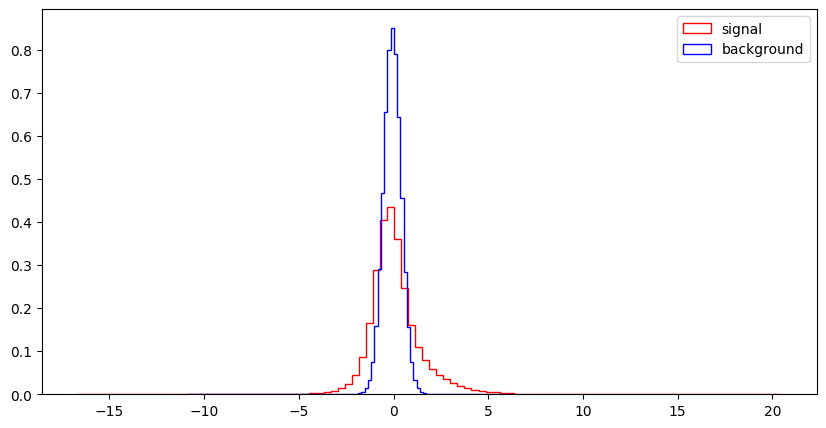

M_R


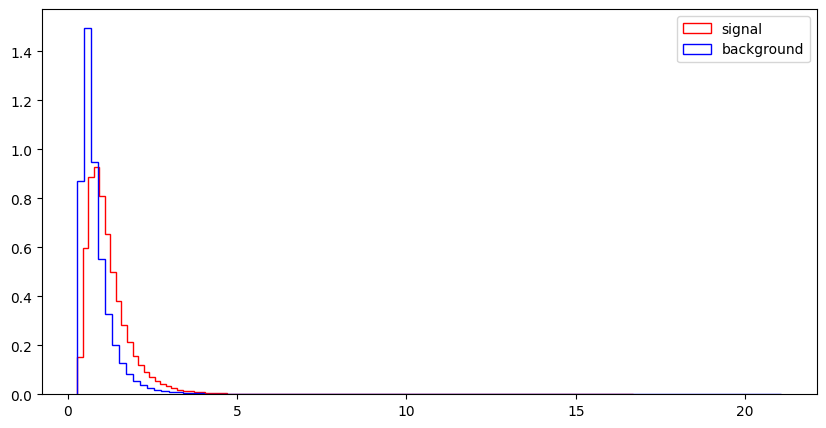

M_TR_2


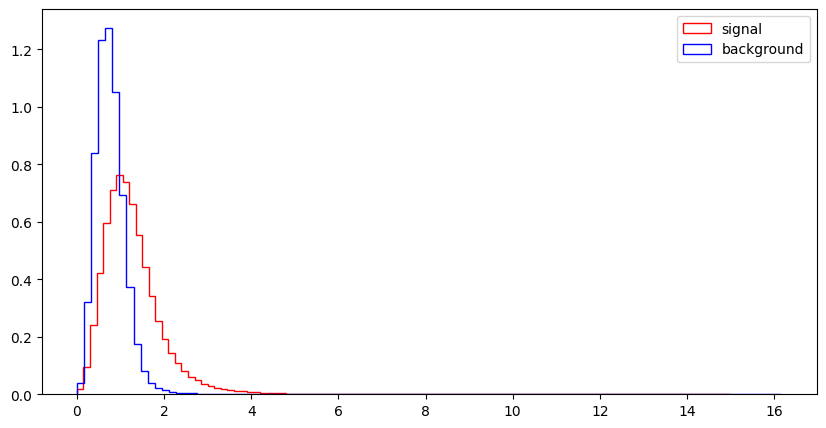

R


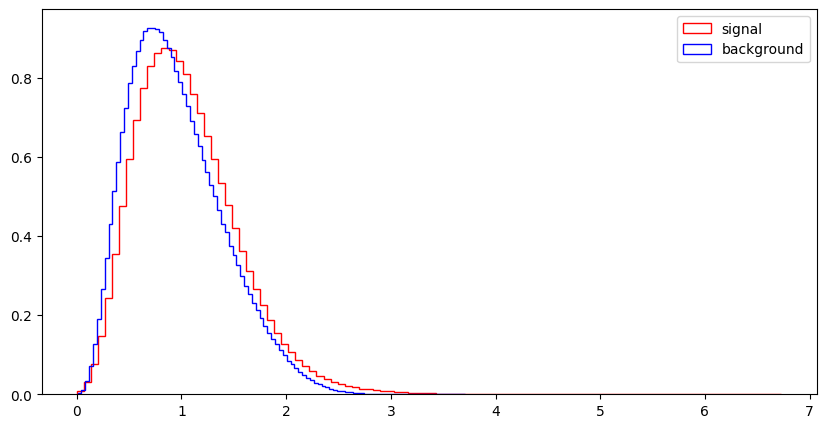

MT2


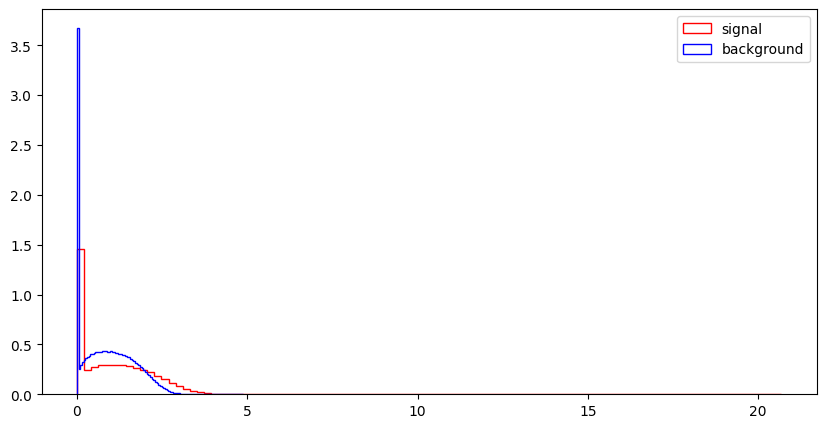

S_R


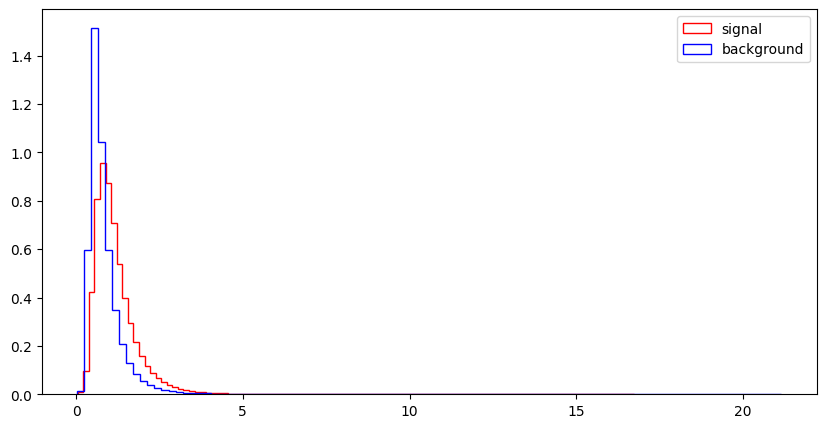

M_Delta_R


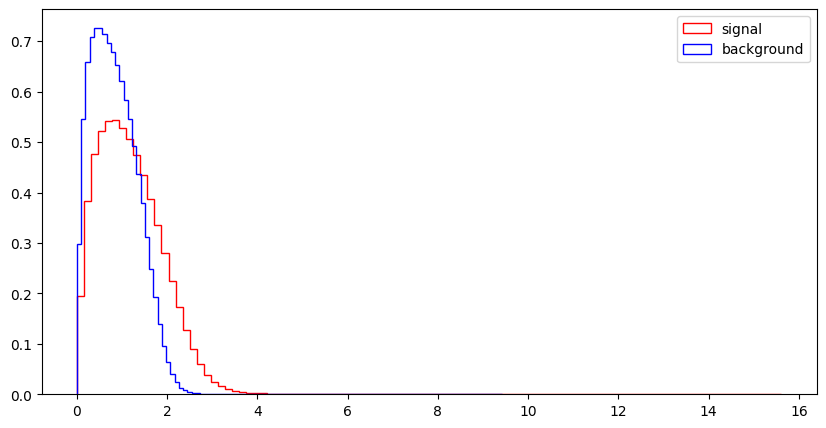

dPhi_r_b


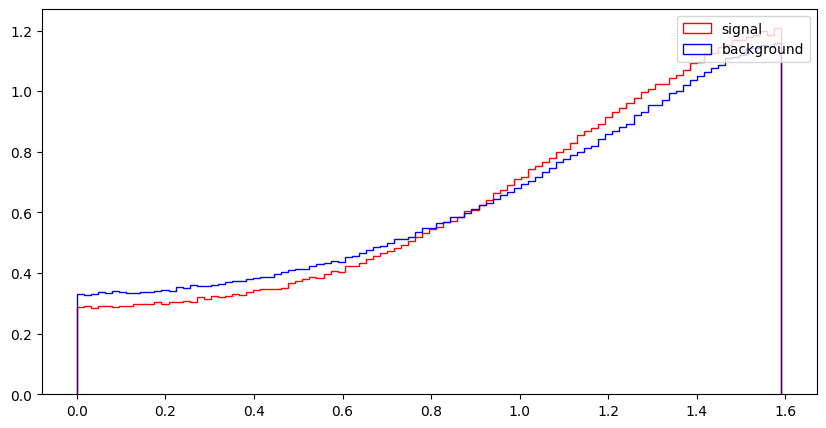

cos_theta_r1


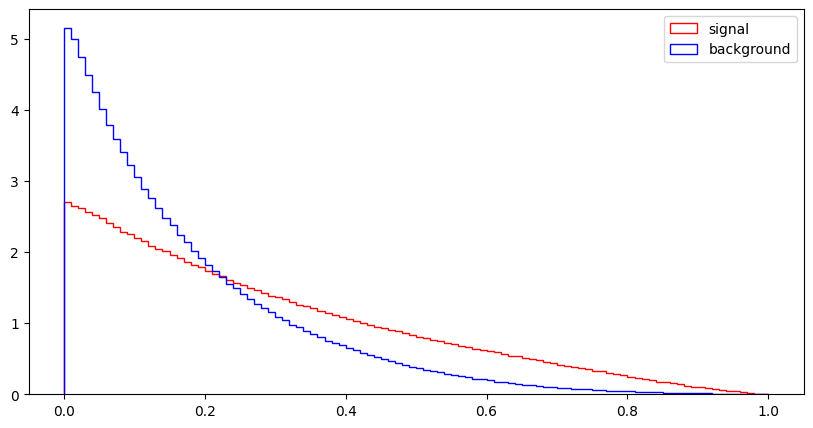

In [13]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("SUSY.csv", header=None, nrows=100000) # only loading part of it b/c it is a large dataset

In [5]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


In [6]:
signal = df[df[0] == 1]
background = df[df[0] == 0]

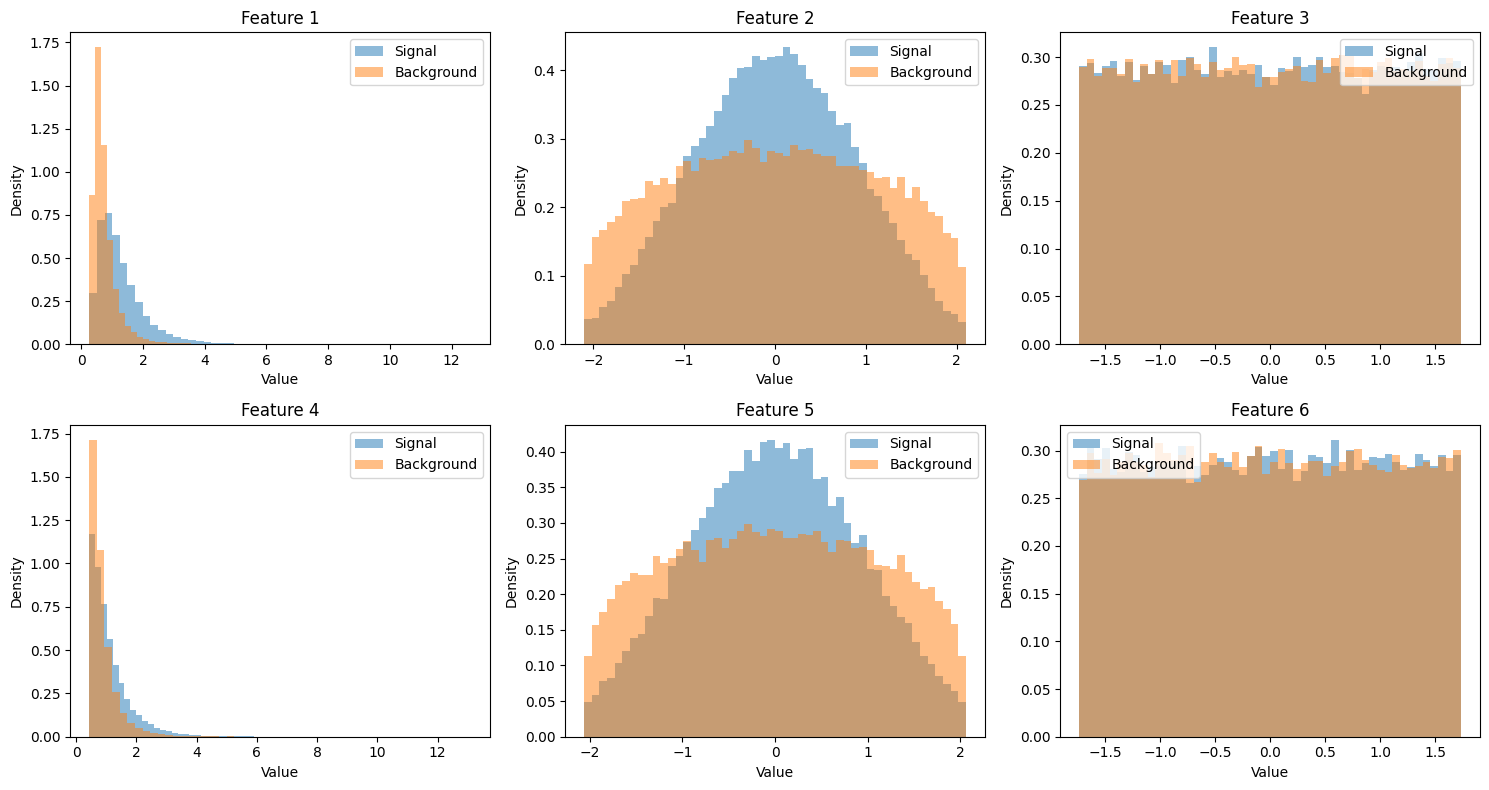

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = [1, 2, 3, 4, 5, 6]

for i, ax in enumerate(axes.flatten()):
    f = features[i]
    
    ax.hist(signal[f], bins=50, alpha=0.5, label="Signal", density=True)
    ax.hist(background[f], bins=50, alpha=0.5, label="Background", density=True)
    
    ax.set_title(f"Feature {f}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [11]:
# part a

def pair_plot(df, cols, label_col=0, sample_size=5000):

    # splitting signal/background
    signal = df_sample[df_sample[label_col] == 1]
    background = df_sample[df_sample[label_col] == 0]

    n = len(cols)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                # histogram
                ax.hist(signal[cols[i]], bins=30, alpha=0.5, label='Signal')
                ax.hist(background[cols[i]], bins=30, alpha=0.5, label='Background')
            else:
                # scatter
                ax.scatter(signal[cols[j]], signal[cols[i]], s=1, alpha=0.3)
                ax.scatter(background[cols[j]], background[cols[i]], s=1, alpha=0.3)

            if i == n - 1:
                ax.set_xlabel(f"Var {cols[j]}")
            if j == 0:
                ax.set_ylabel(f"Var {cols[i]}")

    axes[0, 0].legend()
    plt.tight_layout()
    plt.show()

In [14]:
# part b
df.sample(n=5000)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
50164,1.0,0.659665,0.870248,1.343748,0.706428,0.730389,0.265606,1.182143,-0.980354,1.774543,-0.767362,0.566139,1.114623,1.747114,2.056120,0.668976,1.590439,1.341587,0.190581
19673,1.0,1.187598,-0.318310,-0.007996,1.843387,-0.591243,-1.338507,1.828395,-0.233175,1.119782,1.745559,1.211462,1.379669,1.010606,0.000000,1.190281,0.405524,1.281083,0.279013
74896,0.0,0.327158,0.071188,-1.360601,0.506117,1.261084,1.571759,0.471416,-0.375927,0.707654,0.024547,0.417833,0.538036,1.142682,1.123986,0.395014,0.842184,0.763169,0.109855
93889,1.0,0.549335,0.700854,0.267727,0.694179,2.025335,-1.275657,0.777066,1.692661,0.926333,-0.456544,0.675201,0.759690,0.998436,0.725644,0.722983,0.774471,1.553104,0.215995
32623,0.0,0.633222,-0.184504,-1.254621,0.947046,-1.607635,0.608288,0.383131,0.378748,0.238398,0.045435,0.874784,0.562632,0.570740,0.319204,0.885915,0.374320,1.319431,0.101209
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44615,1.0,0.989839,0.029015,1.478504,1.241153,0.483861,-0.204788,1.192588,0.775477,1.717428,0.940095,0.937434,1.095513,1.037035,0.000000,0.977389,0.994687,1.407455,0.003214
95912,1.0,1.633002,-0.880315,1.481359,0.443578,1.006197,0.654260,1.678687,-0.296779,2.519917,-1.366626,1.377594,1.946754,1.254024,2.334651,1.416090,2.485787,1.322993,0.460797
21044,1.0,0.655816,0.701350,0.423008,0.776600,0.234534,-0.871471,0.994397,0.191175,0.624839,1.255570,0.606044,0.652580,0.955535,0.000000,0.576449,0.255739,1.385705,0.228332
66543,1.0,0.497832,-0.245971,1.619046,0.613690,1.785968,-0.384601,0.227822,-1.501090,0.087044,0.542692,0.830356,0.299108,0.319654,0.000000,0.823502,0.030136,0.917761,0.006088


In [18]:
# we can improve this by using fewer bins or points
# we can compute histograms through numpy

# pair plots are slow b/c each subplot repeatedly loops over
# we can speed this up by randomly subsampling the data

In [20]:
# part c
# in the plots, the variables show more distinct histogram shapes and less overlap between the two classes
# these high-level features combine the low-level measurements 
# this makes it effective for seeing the singal from the background

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [28]:
# part a
import sys
!{sys.executable} -m pip install tabulate
# could not install w/ "!pip install tabulate"

In [30]:
# part b
import numpy as np

# separate features
low_level = df.iloc[:, 1:9].values
high_level = df.iloc[:, 9:19].values
all_features = df.iloc[:, 1:].values

# covariance matrices
cov_all = np.cov(all_features, rowvar=False)
cov_low = np.cov(low_level, rowvar=False)
cov_high = np.cov(high_level, rowvar=False)

# correlation matrices
corr_all = np.corrcoef(all_features, rowvar=False)
corr_low = np.corrcoef(low_level, rowvar=False)
corr_high = np.corrcoef(high_level, rowvar=False)

In [31]:
# part c
from tabulate import tabulate

def format_matrix(matrix, title):
    # round values
    rounded = np.round(matrix, 3)

    # headers
    headers = [f"v{i}" for i in range(rounded.shape[1])]

    print(f"\n{title}")
    print(tabulate(rounded, headers=headers, tablefmt="grid"))

# tables
format_matrix(cov_low, "covariance matrix (low-level)")
format_matrix(corr_low, "correlation matrix (low-level)")

format_matrix(cov_high, "covariance matrix (high-level)")
format_matrix(corr_high, "correlation matrix (high-level)")


covariance matrix (low-level)
+--------+--------+--------+--------+--------+--------+--------+--------+
|     v0 |     v1 |     v2 |     v3 |     v4 |     v5 |     v6 |     v7 |
+========+========+========+========+========+========+========+========+
|  0.466 | -0.002 | -0.002 |  0.301 |  0     |  0.003 |  0.232 | -0.002 |
+--------+--------+--------+--------+--------+--------+--------+--------+
| -0.002 |  1.011 | -0.005 | -0.003 |  0.41  | -0.003 | -0.004 | -0     |
+--------+--------+--------+--------+--------+--------+--------+--------+
| -0.002 | -0.005 |  1.007 |  0.002 | -0     | -0.266 |  0     | -0.186 |
+--------+--------+--------+--------+--------+--------+--------+--------+
|  0.301 | -0.003 |  0.002 |  0.422 |  0     | -0     |  0.081 | -0.003 |
+--------+--------+--------+--------+--------+--------+--------+--------+
|  0     |  0.41  | -0     |  0     |  1.01  | -0.007 | -0     | -0     |
+--------+--------+--------+--------+--------+--------+--------+--------+
|  0.00

In [33]:
# part d
def analyze_correlations(data, cols, title):
    # extracting subset
    subset = data.iloc[:, cols].values

    # computing matrices
    cov = np.cov(subset, rowvar=False)
    corr = np.corrcoef(subset, rowvar=False)

    # formatting
    def print_table(matrix, name):
        rounded = np.round(matrix, 3)
        headers = [f"v{i}" for i in range(rounded.shape[1])]
        print(f"\n{name} ({title})")
        print(tabulate(rounded, headers=headers, tablefmt="grid"))

    # printing results
    print_table(cov, "covariance matrix")
    print_table(corr, "correlation matrix")

Hint: Example code for embedding a `tabulate` table into a notebook:

In [15]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [40]:
# 5.1 
import numpy as np
import matplotlib.pyplot as plt

def plot_feature(df, col):
    # separate signal/background
    sig = df[df[0] == 1][col]
    bkg = df[df[0] == 0][col]

    plt.hist(sig, bins=50, alpha=0.5, label='signal', density=True)
    plt.hist(bkg, bins=50, alpha=0.5, label='background', density=True)
    plt.title(f"feature {col}")
    plt.legend()
    plt.show()

In [41]:
# the optimal selection criterion would depend on how the signal and background distributions differ
# if signal is shifted toward larger values than background, a cut of the form x > xc is optimal
# if shifted toward smaller values x < xc is better
# if signal is away form mean of background, a two-sided cut is best
# it depends on identifying where the signal to background separation is largest

In [42]:
# 5.2 
def compute_tpr_fpr(df, col, direction=">"):
    x = df[col].values
    y = df[0].values  # labels

    thresholds = np.linspace(np.min(x), np.max(x), 100)

    tpr = []
    fpr = []

    for xc in thresholds:
        if direction == ">":
            pred = x > xc
        else:
            pred = x < xc

        # true positives / false positives
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        tn = np.sum((pred == 0) & (y == 0))

        tpr.append(tp / (tp + fn))
        fpr.append(fp / (fp + tn))

    return thresholds, np.array(tpr), np.array(fpr)

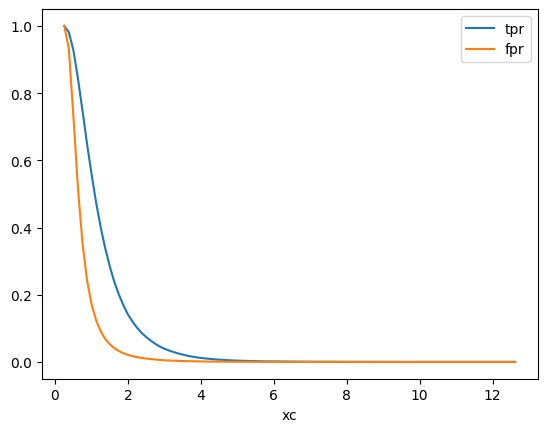

In [43]:
thr, tpr, fpr = compute_tpr_fpr(df, col=1, direction=">")

plt.plot(thr, tpr, label="tpr")
plt.plot(thr, fpr, label="fpr")
plt.xlabel("xc")
plt.legend()
plt.show()

In [44]:
# true positive rate and false positive rate vary as threshold xc changes

In [46]:
# 5.3
def compute_significance(df, col, Ns, Nb, direction=">"):
    x = df[col].values
    y = df[0].values

    thresholds = np.linspace(np.min(x), np.max(x), 100)
    sig = []

    for xc in thresholds:
        if direction == ">":
            pred = x > xc
        else:
            pred = x < xc

        # efficiencies
        eps_s = np.sum((pred == 1) & (y == 1)) / np.sum(y == 1)
        eps_b = np.sum((pred == 1) & (y == 0)) / np.sum(y == 0)

        # expected counts after cut
        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb

        # significance
        if Ns_p + Nb_p > 0:
            s = Ns_p / np.sqrt(Ns_p + Nb_p)
        else:
            s = 0

        sig.append(s)

    return thresholds, np.array(sig)

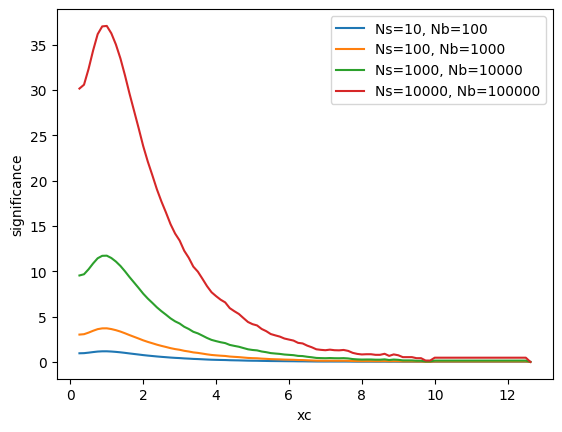

In [47]:
scenarios = [(10,100), (100,1000), (1000,10000), (10000,100000)]

for Ns, Nb in scenarios:
    thr, sig = compute_significance(df, col=1, Ns=Ns, Nb=Nb)
    plt.plot(thr, sig, label=f"Ns={Ns}, Nb={Nb}")

plt.xlabel("xc")
plt.ylabel("significance")
plt.legend()
plt.show()

In [45]:
# the significance depends on selection efficiency and total number of signal and background events

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [48]:
# 6.1
def find_best_cut(df, col, Ns, Nb, direction=">"):
    thresholds, sig = compute_significance(df, col, Ns, Nb, direction)

    # get best xc
    idx = np.argmax(sig)
    best_xc = thresholds[idx]
    best_sig = sig[idx]

    return best_xc, best_sig

In [52]:
features = [1, 2, 3]  # 3 observables
Ns, Nb = 100, 1000

cuts = {}
for col in features:
    xc, s = find_best_cut(df, col, Ns, Nb)
    cuts[col] = xc
    print(f"feature {col}: xc = {xc:.3f}, significance = {s:.3f}")

feature 1: xc = 1.005, significance = 3.706
feature 2: xc = -1.636, significance = 3.044
feature 3: xc = -1.735, significance = 3.015


In [53]:
# 6.2
from tabulate import tabulate

def cut_flow(df, cuts, Ns, Nb, direction=">"):
    data = df.copy()

    results = []
    
    for i, (col, xc) in enumerate(cuts.items()):
        x = data[col].values
        y = data[0].values

        if direction == ">":
            mask = x > xc
        else:
            mask = x < xc

        data = data[mask]

        # efficiencies
        eps_s = np.sum((data[0] == 1)) / np.sum(df[0] == 1)
        eps_b = np.sum((data[0] == 0)) / np.sum(df[0] == 0)

        # expected counts
        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb

        # significance
        sig = Ns_p / np.sqrt(Ns_p + Nb_p) if (Ns_p + Nb_p) > 0 else 0

        results.append([
            f"cut {i+1} (x{col})",
            xc,
            eps_s,
            eps_b,
            Ns_p,
            Nb_p,
            sig
        ])

    headers = ["cut", "xc", "eps_s", "eps_b", "Ns'", "Nb'", "significance"]
    print(tabulate(results, headers=headers, floatfmt=".3f"))

In [54]:
cuts = {1: 0.5, 2: 1.0, 3: -0.2}  # optimal values
cut_flow(df, cuts, Ns=100, Nb=1000)

cut             xc    eps_s    eps_b     Ns'      Nb'    significance
----------  ------  -------  -------  ------  -------  --------------
cut 1 (x1)   0.500    0.931    0.742  93.081  741.731           3.222
cut 2 (x2)   1.000    0.124    0.168  12.396  167.682           0.924
cut 3 (x3)  -0.200    0.068    0.093   6.836   92.827           0.685


In [55]:
# 6.3
def compare_order(df, cut_list, Ns, Nb):
    print("\norder 1:")
    cut_flow(df, dict(cut_list), Ns, Nb)

    print("\norder 2 (reversed):")
    cut_flow(df, dict(reversed(cut_list)), Ns, Nb)

In [56]:
cut_list = [(1, 0.5), (2, 1.0), (3, -0.2)]
compare_order(df, cut_list, Ns=100, Nb=1000)


order 1:
cut             xc    eps_s    eps_b     Ns'      Nb'    significance
----------  ------  -------  -------  ------  -------  --------------
cut 1 (x1)   0.500    0.931    0.742  93.081  741.731           3.222
cut 2 (x2)   1.000    0.124    0.168  12.396  167.682           0.924
cut 3 (x3)  -0.200    0.068    0.093   6.836   92.827           0.685

order 2 (reversed):
cut             xc    eps_s    eps_b     Ns'      Nb'    significance
----------  ------  -------  -------  ------  -------  --------------
cut 1 (x3)  -0.200    0.557    0.556  55.732  556.131           2.253
cut 2 (x2)   1.000    0.075    0.126   7.519  125.571           0.652
cut 3 (x1)   0.500    0.068    0.093   6.836   92.827           0.685


## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [57]:
# 7.1
def compute_roc(df, col, direction=">"):
    x = df[col].values
    y = df[0].values

    thresholds = np.linspace(np.min(x), np.max(x), 200)

    tpr = []
    fpr = []

    for xc in thresholds:
        if direction == ">":
            pred = x > xc
        else:
            pred = x < xc

        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        tn = np.sum((pred == 0) & (y == 0))

        tpr.append(tp / (tp + fn))
        fpr.append(fp / (fp + tn))

    return np.array(fpr), np.array(tpr)

In [58]:
def plot_roc_curves(df, features):
    plt.figure()

    for col in features:
        fpr, tpr = compute_roc(df, col)

        # compute auc using trapezoidal rule
        auc = np.trapz(tpr, fpr)

        plt.plot(fpr, tpr, label=f"x{col} (auc={auc:.3f})")

    plt.plot([0,1], [0,1], 'k--')  # random classifier
    plt.xlabel("fpr")
    plt.ylabel("tpr")
    plt.legend()
    plt.title("roc curves")
    plt.show()

/var/folders/6b/x7rx7l6n5fg6gv5pj45wwc0c0000gn/T/ipykernel_13711/4012110498.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


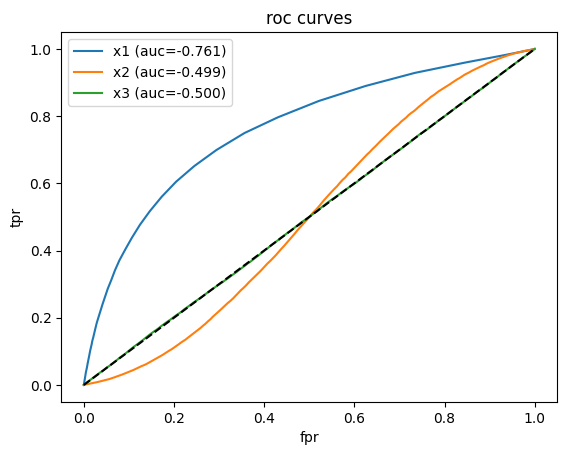

In [59]:
top_features = [1, 2, 3]  # replace with your best ones
plot_roc_curves(df, top_features)

In [60]:
# 7.2
def roc_plot(df, features, directions=None, labels=None):
    plt.figure()

    if directions is None:
        directions = [">"] * len(features)

    for i, col in enumerate(features):
        fpr, tpr = compute_roc(df, col, direction=directions[i])
        auc = np.trapz(tpr, fpr)

        name = labels[i] if labels else f"x{col}"
        plt.plot(fpr, tpr, label=f"{name} (auc={auc:.3f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("fpr")
    plt.ylabel("tpr")
    plt.legend()
    plt.title("roc curves")
    plt.show()

In [ ]:
# 7.3

In [61]:
def apply_cuts(df, cuts, direction=">"):
    data = df.copy()

    for col, xc in cuts:
        if direction == ">":
            data = data[data[col] > xc]
        else:
            data = data[data[col] < xc]

    return data

In [63]:
def roc_after_each_cut(df, cut_list):
    plt.figure()

    current_df = df.copy()

    for i, (col, xc) in enumerate(cut_list):
        if i > 0:
            prev_col, prev_xc = cut_list[i-1]
            current_df = current_df[current_df[prev_col] > prev_xc]

        fpr, tpr = compute_roc(current_df, col)
        auc = np.trapz(tpr, fpr)

        plt.plot(fpr, tpr, label=f"after cut {i+1} (auc={auc:.3f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("fpr")
    plt.ylabel("tpr")
    plt.legend()
    plt.title("roc after successive cuts")
    plt.show()

In [64]:
# 7.4
def compare_cut_orders(df, cut_list):
    plt.figure()

    # original order
    df1 = apply_cuts(df, cut_list)
    fpr1, tpr1 = compute_roc(df1, cut_list[-1][0])
    auc1 = np.trapz(tpr1, fpr1)
    plt.plot(fpr1, tpr1, label=f"original (auc={auc1:.3f})")

    # reversed order
    rev_list = list(reversed(cut_list))
    df2 = apply_cuts(df, rev_list)
    fpr2, tpr2 = compute_roc(df2, rev_list[-1][0])
    auc2 = np.trapz(tpr2, fpr2)
    plt.plot(fpr2, tpr2, label=f"reversed (auc={auc2:.3f})")

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("fpr")
    plt.ylabel("tpr")
    plt.legend()
    plt.title("effect of cut order")
    plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [66]:
# 8.1
import numpy as np
import pandas as pd
df = pd.read_csv("SUSY.csv", header=None, nrows=50000)

X = df.iloc[:, 1:].values   # features
y = df.iloc[:, 0].values    # labels

# split classes
X1 = X[y == 1]  # signal
X0 = X[y == 0]  # background

# mean
m1 = np.mean(X1, axis=0)
m0 = np.mean(X0, axis=0)

# between-class scatter SB
diff = (m1 - m0).reshape(-1, 1)
SB = diff @ diff.T

# within-class scatter SW
SW = np.zeros((X.shape[1], X.shape[1]))

for x in X1:
    d = (x - m1).reshape(-1, 1)
    SW += d @ d.T

for x in X0:
    d = (x - m0).reshape(-1, 1)
    SW += d @ d.T

print("SB shape:", SB.shape)
print("SW shape:", SW.shape)

SB shape: (18, 18)
SW shape: (18, 18)


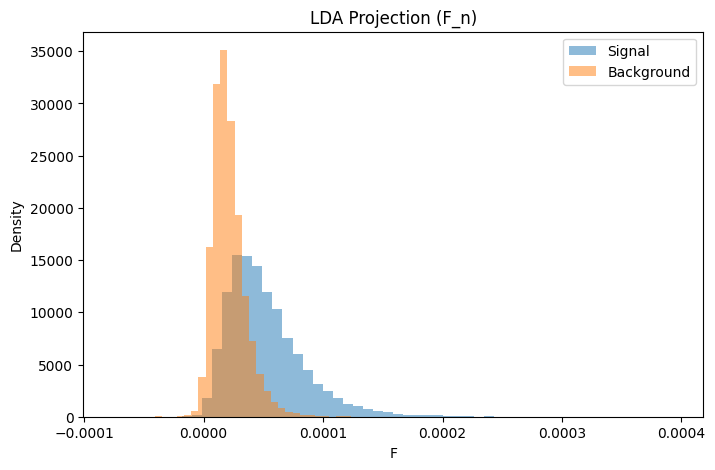

In [67]:
# 8.2
import matplotlib.pyplot as plt

w = np.linalg.pinv(SW) @ (m1 - m0)

F = X @ w

# separate projections
F1 = F[y == 1]
F0 = F[y == 0]

# plot histogram
plt.figure(figsize=(8,5))
plt.hist(F1, bins=50, alpha=0.5, label="Signal", density=True)
plt.hist(F0, bins=50, alpha=0.5, label="Background", density=True)

plt.legend()
plt.title("LDA Projection (F_n)")
plt.xlabel("F")
plt.ylabel("Density")
plt.show()

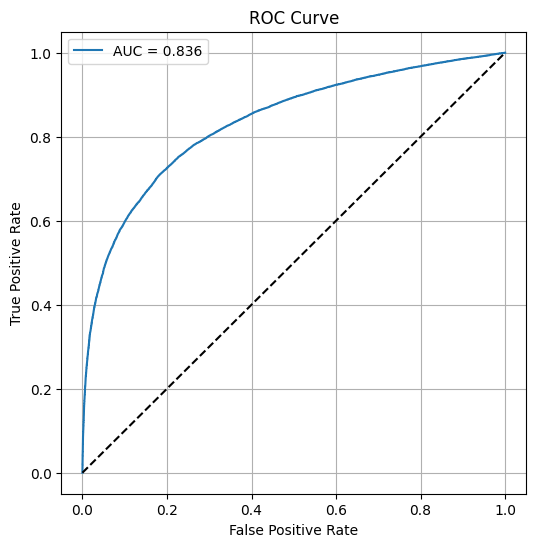

In [68]:
# 8.3
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y, F)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [69]:
# 8.4
best_sig = 0
best_thresh = 0

for t in thresholds:
    pred_signal = F >= t # predicted signal
     
    S = np.sum((pred_signal == 1) & (y == 1))
    B = np.sum((pred_signal == 1) & (y == 0))
    
    if S + B > 0:
        sig = S / np.sqrt(S + B)
        
        if sig > best_sig:
            best_sig = sig
            best_thresh = t

print("Max significance:", best_sig)
print("Best threshold:", best_thresh)

Max significance: 113.4170630111028
Best threshold: 2.7227156484102493e-05


In [70]:
# ChatGPT helped me a lot.